<a href="https://colab.research.google.com/github/nachman1998/workshop/blob/main/workshop_modeltreain.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm
import timm
from sklearn.kernel_approximation import Nystroem
from sklearn.linear_model import SGDOneClassSVM
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
import numpy as np
from sympy.tensor import tensor

In [2]:
import numpy as np

def shift_x_and_add(hists, dx):
    """
    hists: (N, 1, H, W)
    dx: positive -> shift right, negative -> shift left
    """
    shifted = np.zeros_like(hists)

    if dx > 0:
        shifted[:, :, :, dx:] = hists[:, :, :, :-dx]
    elif dx < 0:
        dx = -dx
        shifted[:, :, :, :-dx] = hists[:, :, :, dx:]
    else:
        shifted = hists.copy()
    hists=hists + shifted
    dx=dx+5
    shifted = np.zeros_like(hists)

    if dx > 0:
        shifted[:, :, :, dx:] = hists[:, :, :, :-dx]
    elif dx < 0:
        dx = -dx
        shifted[:, :, :, :-dx] = hists[:, :, :, dx:]
    else:
        shifted = hists.copy()
    return hists + shifted

In [3]:
m = timm.create_model('mobilenetv4_conv_small.e2400_r224_in1k', pretrained=True, num_classes=0,in_chans=1)
#m = timm.create_model('eva02_large_patch14_448.mim_m38m_ft_in22k_in1k', pretrained=True, num_classes=0,in_chans=1)



model.safetensors: reconstructing file:   0%|          |  0.00B / 15.2MB            

model.safetensors: downloading bytes:           |  0.00B            

In [95]:
m.patch_embed.strict_img_size = False

In [4]:
def feture_extract(m, X, batch=32):
    # Select best available device (CUDA -> MPS/Apple Silicon -> CPU)
    if torch.cuda.is_available():
        device = torch.device("cuda")
    elif torch.backends.mps.is_available():
        device = torch.device("mps")
    else:
        device = torch.device("cpu")

    m = m.to(device)
    m.eval()

    loader = DataLoader(
        TensorDataset(X),
        batch_size=batch,
        shuffle=False,
    )

    features = []

    with torch.no_grad():
        for (x,) in tqdm(loader, desc="Extracting features"):
            x = x.to(device)
            features.append(m(x))

    # Move concatenated output back to CPU before converting to NumPy
    return torch.cat(features, dim=0).cpu().numpy()

In [ ]:

def feture_extract(m,X,batch=32):
    m.eval()
    loader = DataLoader(
        TensorDataset(X),
        batch_size=batch,
        shuffle=False,
    )

    features = []

    with torch.no_grad():
        for (x,) in tqdm(loader, desc="Extracting features"):
            features.append(m(x))

    return torch.cat(features).cpu().numpy()

In [6]:



random_state=42
path_test=r"/content/yot_all_test.npy"
path_train=r"/content/yot_all_train.npy"

m.eval()

X_train=np.load(path_train)
X_test=np.load(path_test)
X_test_mod=np.load(path_test)
max_val=max(X_train.max(),X_test.max())
X_train=X_train/max_val
X_test=X_test/max_val
X_test_mod=X_test_mod/max_val
X_train = torch.from_numpy(X_train).unsqueeze(1).float()
X_test = torch.from_numpy(X_test).unsqueeze(1).float()
X_test_mod = torch.from_numpy(X_test_mod).unsqueeze(1).float()
X_test_mod = shift_x_and_add(X_test_mod, dx=20)

/tmp/ipykernel_413/235109600.py:11: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  shifted[:, :, :, dx:] = hists[:, :, :, :-dx]
/tmp/ipykernel_413/235109600.py:17: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  hists=hists + shifted
/tmp/ipykernel_413/235109600.py:22: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  shifted[:, :, :, dx:] = hists[:, :, :, :-dx]
/tmp/ipykernel_413/235109600.py:28: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return hists + shifted


In [7]:
X_train=feture_extract(m,X_train)
X_test=feture_extract(m,X_test)
X_test_mod=feture_extract(m,X_test_mod)
print(f'Unpooled shape: {X_train.shape}')


Extracting features: 100%|██████████| 6/6 [00:00<00:00, 106.96it/s]

Unpooled shape: (715, 1280)


In [75]:
'''scaler = StandardScaler()

X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)
X_test_mod=scaler.transform(X_test_mod)'''

In [8]:
print(X_train.shape)
print(X_test.shape)

(715, 1280)
(179, 1280)


In [11]:
print(X_train[3])

[ 1.103465    1.0848858  -0.8525601  ... -0.729487   -1.001385
  0.39576945]


In [87]:
import itertools
import numpy as np
import pandas as pd
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score

# build combined eval set with ground truth labels
X_eval = np.vstack([X_test, X_test_mod])
y_eval = np.concatenate([
    np.ones(len(X_test)),        # normal = 1
    -np.ones(len(X_test_mod))    # anomaly = -1
])

nu_grid = [ 0.01, 0.05, 0.1, 0.14,0.2, 0.3,0.4,0.5]
gamma_grid = [ 2, 5, 10,20,30,40,50]
n_components_grid = [100, 200]  # optional third axis

results = []

for nu, gamma in itertools.product(nu_grid, gamma_grid):
    transform = Nystroem(gamma=gamma, random_state=random_state)
    clf_sgd = SGDOneClassSVM(
        nu=nu, shuffle=True, fit_intercept=True,
        random_state=random_state, tol=1e-4
    )
    pipe = make_pipeline(transform, clf_sgd)
    pipe.fit(X_train)

    y_pred = pipe.predict(X_eval)          # -1 / 1
    scores = pipe.decision_function(X_eval)  # higher = more "normal"

    f1 = f1_score(y_eval, y_pred, pos_label=-1)          # anomaly = positive class
    precision = precision_score(y_eval, y_pred, pos_label=-1, zero_division=0)
    recall = recall_score(y_eval, y_pred, pos_label=-1, zero_division=0)
    auc = roc_auc_score((y_eval == 1).astype(int), scores)  # 1=normal for AUC convention

    # also track how well it does on train (shouldn't over-flag normal training data)
    y_pred_train = pipe.predict(X_train)
    train_normal_acc = (y_pred_train == 1).mean()

    results.append({
        'nu': nu, 'gamma': gamma,
        'f1': f1, 'precision': precision, 'recall': recall, 'auc': auc,
        'train_normal_acc': train_normal_acc
    })

results_df = pd.DataFrame(results).sort_values('f1', ascending=False)
print(results_df.head(15))

      nu  gamma  n_components        f1  precision    recall       auc  \
28  0.20      2           200  0.734864   0.586667  0.983240  0.645454   
37  0.30     10           200  0.710579   0.552795  0.994413  0.591960   
36  0.30      5           200  0.707819   0.560261  0.960894  0.659358   
38  0.30     20           200  0.703340   0.542424  1.000000  0.581755   
15  0.10      5           200  0.549020   0.921053  0.391061  0.736712   
8   0.05      5           200  0.547619   0.945205  0.385475  0.732483   
29  0.20      5           200  0.546816   0.829545  0.407821  0.708186   
22  0.14      5           200  0.544747   0.897436  0.391061  0.720093   
9   0.05     10           200  0.544000   0.957746  0.379888  0.765660   
10  0.05     20           200  0.542636   0.886076  0.391061  0.563512   
16  0.10     10           200  0.542636   0.886076  0.391061  0.717378   
11  0.05     30           200  0.541833   0.944444  0.379888  0.785728   
24  0.14     20           200  0.53846

In [21]:
import itertools
import numpy as np
import pandas as pd
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score
from sklearn.svm import OneClassSVM

# build combined eval set with ground truth labels
X_eval = np.vstack([X_test, X_test_mod])
y_eval = np.concatenate([
    np.ones(len(X_test)),        # normal = 1
    -np.ones(len(X_test_mod))    # anomaly = -1
])

nu_grid = [ 0.01, 0.05, 0.1, 0.14,0.2, 0.3,0.4,0.5]
gamma_grid = [ 2, 5, 10,20,30,40,50]
n_components_grid = [100, 200]  # optional third axis

results = []

for nu, gamma in itertools.product(nu_grid, gamma_grid):
    clf = OneClassSVM(gamma=gamma, kernel="rbf", nu=nu)
    clf.fit(X_train)


    y_pred = clf.predict(X_eval)          # -1 / 1
    scores = clf.decision_function(X_eval)  # higher = more "normal"

    f1 = f1_score(y_eval, y_pred, pos_label=-1)          # anomaly = positive class
    precision = precision_score(y_eval, y_pred, pos_label=-1, zero_division=0)
    recall = recall_score(y_eval, y_pred, pos_label=-1, zero_division=0)
    auc = roc_auc_score((y_eval == 1).astype(int), scores)  # 1=normal for AUC convention

    # also track how well it does on train (shouldn't over-flag normal training data)
    y_pred_train = clf.predict(X_train)
    train_normal_acc = (y_pred_train == 1).mean()

    results.append({
        'nu': nu, 'gamma': gamma,
        'f1': f1, 'precision': precision, 'recall': recall, 'auc': auc,
        'train_normal_acc': train_normal_acc
    })

results_df = pd.DataFrame(results).sort_values('f1', ascending=False)
print(results_df.head(15))

      nu  gamma        f1  precision    recall       auc  train_normal_acc
4   0.01     30  0.718367   0.565916  0.983240  0.622827          0.506294
5   0.01     40  0.710579   0.552795  0.994413  0.581567          0.464336
15  0.10      5  0.571429   0.873563  0.424581  0.650666          0.881119
9   0.05     10  0.568182   0.882353  0.418994  0.667863          0.948252
22  0.14      5  0.565056   0.844444  0.424581  0.648731          0.846154
2   0.01     10  0.564885   0.891566  0.413408  0.668113          0.951049
16  0.10     10  0.563910   0.862069  0.418994  0.663931          0.890909
1   0.01      5  0.563707   0.912500  0.407821  0.681783          0.972028
23  0.14     10  0.554745   0.800000  0.424581  0.648825          0.841958
7   0.05      2  0.553360   0.945946  0.391061  0.653350          0.953846
13  0.05     50  0.552632   0.454874  0.703911  0.527793          0.440559
29  0.20      5  0.551471   0.806452  0.418994  0.621298          0.804196
14  0.10      2  0.550388

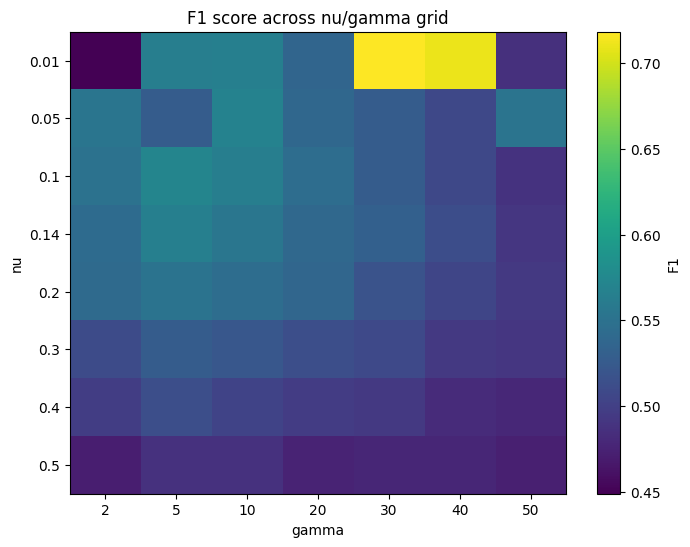

In [22]:
import matplotlib.pyplot as plt

pivot = results_df.pivot_table(index='nu', columns='gamma', values='f1')
plt.figure(figsize=(8,6))
plt.imshow(pivot, aspect='auto', cmap='viridis')
plt.colorbar(label='F1')
plt.xticks(range(len(pivot.columns)), pivot.columns)
plt.yticks(range(len(pivot.index)), pivot.index)
plt.xlabel('gamma')
plt.ylabel('nu')
plt.title('F1 score across nu/gamma grid')
plt.show()

In [9]:
from sklearn.svm import OneClassSVM
nu = 0.2
gamma = 2.0

# Fit the One-Class SVM
clf = OneClassSVM(gamma=gamma, kernel="rbf", nu=nu)
clf.fit(X_train)

OneClassSVM(gamma=2.0, nu=0.2)

In [11]:
y_pred_train = clf.predict(X_train)
y_pred_test = clf.predict(X_test)
#y_pred_outliers = clf.predict(X_outliers)
n_error_train = y_pred_train[y_pred_train == -1].size
n_error_test = y_pred_test[y_pred_test == -1].size
#n_error_outliers = y_pred_outliers[y_pred_outliers == 1].size

In [17]:
print(n_error_test)

20


In [18]:

# OCSVM hyperparameters
nu = 0.2
gamma = 2

# Fit the One-Class SVM using a kernel approximation and SGD
transform = Nystroem(gamma=gamma, random_state=random_state)
clf_sgd = SGDOneClassSVM(
    nu=nu, shuffle=True, fit_intercept=True, random_state=random_state, tol=1e-4,verbose=1
)
pipe_sgd = make_pipeline(transform, clf_sgd)
pipe_sgd.fit(X_train)

-- Epoch 1
Norm: 1.13, NNZs: 100, Bias: 0.316551, T: 715, Avg. loss: 0.012642
Total training time: 0.00 seconds.
-- Epoch 2
Norm: 1.13, NNZs: 100, Bias: 0.292450, T: 1430, Avg. loss: 0.012017
Total training time: 0.00 seconds.
-- Epoch 3
Norm: 1.14, NNZs: 100, Bias: 0.286180, T: 2145, Avg. loss: 0.011972
Total training time: 0.00 seconds.
-- Epoch 4
Norm: 1.14, NNZs: 100, Bias: 0.283004, T: 2860, Avg. loss: 0.011396
Total training time: 0.00 seconds.
-- Epoch 5
Norm: 1.15, NNZs: 100, Bias: 0.288374, T: 3575, Avg. loss: 0.012257
Total training time: 0.00 seconds.
-- Epoch 6
Norm: 1.14, NNZs: 100, Bias: 0.280893, T: 4290, Avg. loss: 0.011030
Total training time: 0.00 seconds.
-- Epoch 7
Norm: 1.14, NNZs: 100, Bias: 0.277220, T: 5005, Avg. loss: 0.011595
Total training time: 0.01 seconds.
-- Epoch 8
Norm: 1.15, NNZs: 100, Bias: 0.281038, T: 5720, Avg. loss: 0.012190
Total training time: 0.01 seconds.
-- Epoch 9
Norm: 1.15, NNZs: 100, Bias: 0.284118, T: 6435, Avg. loss: 0.011754
Total trai

Pipeline(steps=[('nystroem', Nystroem(gamma=2, random_state=42)),
                ('sgdoneclasssvm',
                 SGDOneClassSVM(nu=0.2, random_state=42, tol=0.0001,
                                verbose=1))])

In [19]:
y_pred_train_sgd = pipe_sgd.predict(X_train)
y_pred_test_sgd = pipe_sgd.predict(X_test)
#y_pred_outliers_sgd = pipe_sgd.predict(X_outliers)
n_error_train_sgd = y_pred_train_sgd[y_pred_train_sgd == -1].size
n_error_test_sgd = y_pred_test_sgd[y_pred_test_sgd == -1].size
#n_error_outliers_sgd = y_pred_outliers_sgd[y_pred_outliers_sgd == 1].size

In [20]:
print(n_error_test_sgd)

124


In [18]:
x=np.load(path_test)
x=torch.from_numpy(x).unsqueeze(1).float()

In [19]:
x.shape

torch.Size([179, 1, 214, 214])

In [20]:
x=x.numpy()

In [21]:
x=x
x=x*90

x.shape


(179, 1, 214, 214)

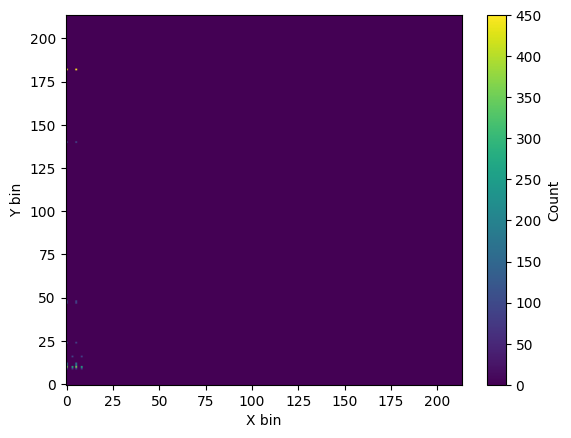

In [22]:
import matplotlib.pyplot as plt
H=x[1,0]
dx = 5  # shift by 5 bins to the right

H_shifted = np.zeros_like(H)
H_shifted[:, dx:] = H[:, :-dx]

H_new = H + H_shifted
plt.imshow(
    H_new,
    origin="lower",
    aspect="auto",
    cmap="viridis"
)
plt.colorbar(label="Count")
plt.xlabel("X bin")
plt.ylabel("Y bin")
plt.show()

In [25]:
X_new = shift_x_and_add(x, dx=20)


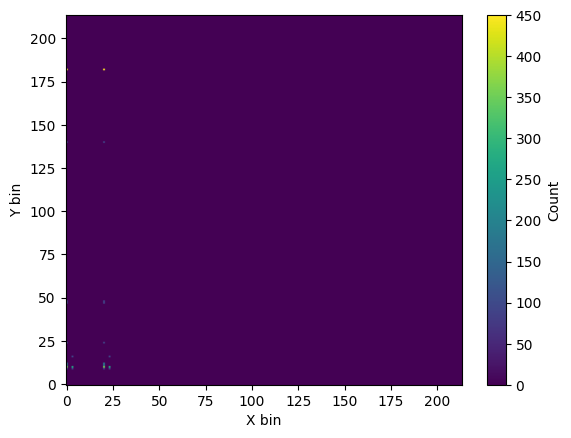

In [26]:
H=X_new[1,0]

plt.imshow(
    H,
    origin="lower",
    aspect="auto",
    cmap="viridis"
)
plt.colorbar(label="Count")
plt.xlabel("X bin")
plt.ylabel("Y bin")
plt.show()

In [27]:
x=X_new

In [28]:

X_test_90=feture_extract(m,torch.tensor(x))

scaler = StandardScaler()


Extracting features: 100%|██████████| 6/6 [00:01<00:00,  3.29it/s]


In [27]:
#X_test_90=scaler.fit_transform(X_test_90)

In [29]:
y_pred_test_sgd = pipe_sgd.predict(X_test_90)


In [32]:
n_error_test_sgd = y_pred_test_sgd[y_pred_test_sgd == -1].size
print(n_error_test_sgd)

0
